### sklearn练习

##### 模型基本流程

In [ ]:
from sklearn.linear_model import LinearRegression
#获取模型
model = LinearRegression()
#训练模型
model.fit(X_train, y_train)
#预测
y_pred = model.predict(X_test)
#评估模型
score = model.score(X_test, y_test)

##### 线性回归练习

In [ ]:
#导入数据集
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
print(x.shape,y.shape,diabetes.feature_names)

(442, 10) (442,) ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [ ]:
#划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, 
    test_size=0.2,#测试集占20% 
    random_state=42)#保证每次划分一致（不随机

In [ ]:
#获取模型
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)#利用正规方程直接解出w,b
print(model.coef_,model.intercept_)#打印w,b

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743] 151.34560453985995


In [ ]:
#看模型预测情况
y_pred = model.predict(X_test)
print(y_pred[:5])

[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]


In [ ]:
#看训练误差和R2
from sklearn.metrics import mean_squared_error
train_mse = mean_squared_error(y_train, model.predict(X_train))
r2 = model.score(X_test, y_test)
print("mse",train_mse)
print('R2',r2)

mse 2868.5497028355776
R2 0.4526027629719195


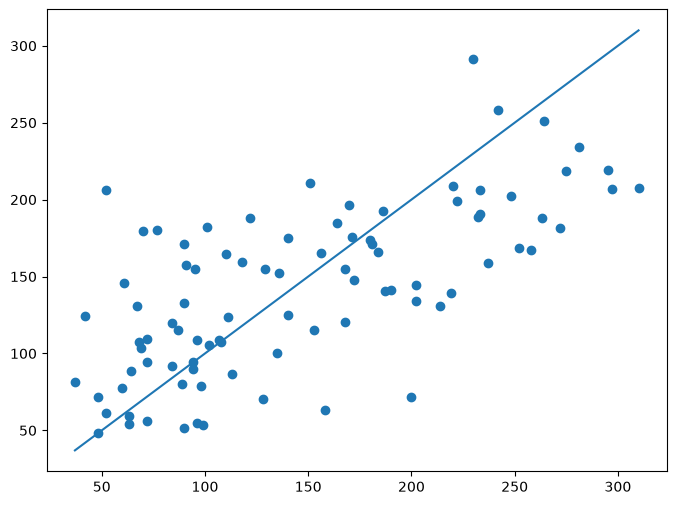

In [ ]:
#绘图真实值与测试值散点图
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
          [y_test.min(), y_test.max()])
plt.xlabel('真实值')
plt.ylabel('预测值')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 中文显示设置
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 加载数据
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. 训练线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 模型预测与评估
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
residuals = y_test - y_pred

print("特征名称：", feature_names)
print("模型系数：", model.coef_)
print("模型截距：", model.intercept_)
print(f"训练集 MSE：{train_mse:.2f}")
print(f"测试集 MSE：{test_mse:.2f}")
print(f"测试集 RMSE：{test_rmse:.2f}")
print(f"测试集 MAE：{test_mae:.2f}")
print(f"测试集 R²：{test_r2:.3f}")
print("前 5 个预测值：", np.round(y_pred[:5], 2))

# 5. 创建综合可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("糖尿病数据集——多元线性回归模型分析", fontsize=18, fontweight="bold")

# 图1：真实值与预测值
ax = axes[0, 0]
scatter = ax.scatter(
    y_test, y_pred,
    c=np.abs(residuals),
    cmap="viridis",
    s=65,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.6
)

value_min = min(y_test.min(), y_pred.min())
value_max = max(y_test.max(), y_pred.max())

ax.plot(
    [value_min, value_max],
    [value_min, value_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="理想预测线"
)

ax.set(
    title=f"真实值与预测值（R² = {test_r2:.3f}）",
    xlabel="真实值",
    ylabel="预测值"
)
ax.legend()
ax.grid(alpha=0.25)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("绝对预测误差")

# 图2：按真实值排序后的预测对比
ax = axes[0, 1]
sort_index = np.argsort(y_test)
sorted_true = y_test[sort_index]
sorted_pred = y_pred[sort_index]
sample_index = np.arange(len(y_test))

ax.plot(
    sample_index, sorted_true,
    color="#1f77b4",
    marker="o",
    markersize=4,
    linewidth=2,
    label="真实值"
)
ax.plot(
    sample_index, sorted_pred,
    color="#ff7f0e",
    marker="s",
    markersize=3,
    linewidth=1.8,
    label="预测值"
)
ax.fill_between(
    sample_index,
    sorted_true,
    sorted_pred,
    color="gray",
    alpha=0.15,
    label="预测误差"
)

ax.set(
    title="测试样本真实值与预测值对比",
    xlabel="测试样本（按真实值从小到大排序）",
    ylabel="疾病进展指标"
)
ax.legend()
ax.grid(alpha=0.25)

# 图3：残差分析
ax = axes[1, 0]
ax.scatter(
    y_pred, residuals,
    color="#2ca02c",
    s=55,
    alpha=0.75,
    edgecolors="white",
    linewidths=0.5
)
ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="零误差线"
)

ax.set(
    title=f"残差分布（RMSE = {test_rmse:.2f}，MAE = {test_mae:.2f}）",
    xlabel="预测值",
    ylabel="残差（真实值 - 预测值）"
)
ax.legend()
ax.grid(alpha=0.25)

# 图4：特征系数重要性
ax = axes[1, 1]
coef_order = np.argsort(model.coef_)
sorted_coef = model.coef_[coef_order]
sorted_features = np.array(feature_names)[coef_order]
colors = np.where(sorted_coef >= 0, "#d62728", "#1f77b4")

bars = ax.barh(
    sorted_features,
    sorted_coef,
    color=colors,
    alpha=0.8
)
ax.axvline(0, color="black", linewidth=1)

for bar, coefficient in zip(bars, sorted_coef):
    offset = 8 if coefficient >= 0 else -8
    align = "left" if coefficient >= 0 else "right"
    ax.annotate(
        f"{coefficient:.1f}",
        xy=(coefficient, bar.get_y() + bar.get_height() / 2),
        xytext=(offset, 0),
        textcoords="offset points",
        va="center",
        ha=align,
        fontsize=9
    )

ax.set(
    title="各特征的线性回归系数",
    xlabel="回归系数（红色为正，蓝色为负）",
    ylabel="特征"
)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### 逻辑回归模型练习

In [3]:
#导入数据
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

In [31]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
#划分测试集和训练集
#数据量小，不用划分验证集，在训练集内部，使用交叉验证来选择模型参数
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#交叉验证选取最优参数
from sklearn.model_selection import GridSearchCV
model = LogisticRegression(max_iter=1000)
#参数c代表正则项，solver代表优化算法
'''
lbfgs适合中小数据集，支持 L2 和多分类
liblinear适合小数据集,支持 L1 稀疏解，但只能做二分类 OvR
saga适合大数据集
'''
param_grid = {"C":[0.01,0.1,1,10,100]}
grid = GridSearchCV(model,param_grid,cv=5)
grid.fit(X_train,y_train)
print(grid.best_params_,grid.best_score_)

{'C': 1} 0.9666666666666666


In [ ]:
'''
在测试集上再次评估模型，测试集上效果不好，
1.有可能是参数搜索不到位
2.数据量不够
...过拟合的其他原因
混淆矩阵：
    真阳性 |假阴性
     _____|_____
    假阳性 |真阴性
     _____|_____
          
   
'''
best_model = grid.best_estimator_
print(best_model.score(X_test,y_test))

1.0


#### 随机森林练习

In [ ]:
from sklearn.ensemble import RandomForestClassifier
#随机森林不需要特征缩放，既可以回归也可以预测
model = RandomForestClassifier()
'''
n_estimators是树的数量
max_depth是树的深度
max_features是树随机选择的特征数量
min_samples_split是树分裂数量底线
'''
model.fit(X_train,y_train)


#### SVM练习

In [ ]:
'''
SVC找到一个最优的超平面来区分不同类别的数据点
SVR找到一个最优的超平面来拟合数据点（数据点在边界条件内）
SVC用于分类问题，SVR用于回归问题
LinearSVC是SVC的线性版本
LinearSVR是SVR的线性版本
线性核不映射到高维空间
'''
#SVM必须进行数据标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
#这里测试集用的是训练值的μ和σ（不能知道其他测试集的数据
X_test_scaled = scaler.transform(X_test)
from sklearn.svm import SVC
model = SVC()
'''
参数kernel，分为线性核和rbf核
参数C，C越大，对于在决策边界内的点更严格
参数gamma，在rbf核下，gamma越大，模型对于训练集
    的拟合程度越好
'''
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
#这里的score在预测时是正确率，在回归时是r2
score = model.score(X_test_scaled,y_test)
print(score)


1.0


#### K-means练习 

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
''' 
n_cluster表示分类的数量
kmeans++分类，离得远的选中的概率更大
'''
model.fit(X)

d:\miniconda\envs\6661kai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 4)",

In [16]:
y_pred = model.predict(X_test)
labels = model.labels_
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [18]:
centers = model.cluster_centers_
centers

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [ ]:
#intertia表示所有簇内样本到自己簇中心的距离平方和
print(model.inertia_)

78.85144142614601


#### PCA练习

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
#训练并得到降维后的新数据
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(150, 2)